# 📘 Module 1.1 — Python & NumPy Basics for Deep Learning

**Goal:** Refresh core Python and NumPy skills needed for deep learning.

## Why This Matters for ADAS
Every deep learning model — from a simple CNN to a complex VLA — is built on **matrix operations**. NumPy is the foundation that PyTorch is built upon. Understanding it will help you debug models, preprocess sensor data, and understand what happens inside neural networks.

---

## 1. Python Refresher — Key Concepts

In [1]:
# --- List Comprehensions (heavily used in data pipelines) ---
# Example: Generate a list of squared values
squares = [x**2 for x in range(10)]
print("Squares:", squares)

# Filtering: keep only even squares
even_squares = [x**2 for x in range(10) if x % 2 == 0]
print("Even squares:", even_squares)

Squares: [0, 1, 4, 9, 16, 25, 36, 49, 64, 81]
Even squares: [0, 4, 16, 36, 64]


In [2]:
# --- Dictionaries (used everywhere in configs, model parameters) ---
model_config = {
    'learning_rate': 0.001,
    'batch_size': 32,
    'epochs': 10,
    'architecture': 'ResNet50'
}

print(f"Training {model_config['architecture']} for {model_config['epochs']} epochs")
print(f"Learning rate: {model_config['learning_rate']}")

Training ResNet50 for 10 epochs
Learning rate: 0.001


In [3]:
# --- Functions & Lambda (used in data transforms) ---
def normalize(value, min_val, max_val):
    """Min-max normalization — commonly used in preprocessing."""
    return (value - min_val) / (max_val - min_val)

# Lambda version (used in PyTorch transforms)
normalize_lambda = lambda v, lo, hi: (v - lo) / (hi - lo)

print("Normalized 75 in [0, 100]:", normalize(75, 0, 100))
print("Lambda result:", normalize_lambda(75, 0, 100))

Normalized 75 in [0, 100]: 0.75
Lambda result: 0.75


In [4]:
# --- Classes (PyTorch models are Python classes) ---
class Sensor:
    """Simple sensor class — ADAS uses cameras, LiDAR, radar."""
    def __init__(self, name, sensor_type, resolution):
        self.name = name
        self.sensor_type = sensor_type
        self.resolution = resolution
    
    def __repr__(self):
        return f"Sensor({self.name}, {self.sensor_type}, {self.resolution})"
    
    def get_data_shape(self):
        if self.sensor_type == 'camera':
            return (3, self.resolution[0], self.resolution[1])  # C, H, W
        elif self.sensor_type == 'lidar':
            return (self.resolution, 4)  # N points x (x, y, z, intensity)

front_camera = Sensor('Front Camera', 'camera', (1080, 1920))
lidar = Sensor('Top LiDAR', 'lidar', 100000)

print(front_camera)
print(f"Camera data shape: {front_camera.get_data_shape()}")
print(f"LiDAR data shape: {lidar.get_data_shape()}")

Sensor(Front Camera, camera, (1080, 1920))
Camera data shape: (3, 1080, 1920)
LiDAR data shape: (100000, 4)


---
## 2. NumPy Fundamentals

In [5]:
import numpy as np

# --- Array Creation ---
# 1D array (like a sensor reading over time)
speed_readings = np.array([30.5, 32.1, 31.8, 33.0, 34.2])
print("Speed readings:", speed_readings)
print("Shape:", speed_readings.shape)
print("Data type:", speed_readings.dtype)

# 2D array (like a grayscale image)
image_patch = np.random.randint(0, 256, size=(4, 4), dtype=np.uint8)
print("\nImage patch (4x4):")
print(image_patch)

# 3D array (like an RGB image: Height x Width x Channels)
rgb_image = np.random.randint(0, 256, size=(3, 224, 224), dtype=np.uint8)
print(f"\nRGB image shape (C, H, W): {rgb_image.shape}")

Speed readings: [30.5 32.1 31.8 33.  34.2]
Shape: (5,)
Data type: float64

Image patch (4x4):
[[ 13 134  37 184]
 [ 88  97 220 172]
 [ 98  86 102  83]
 [118 160 228  27]]

RGB image shape (C, H, W): (3, 224, 224)


In [6]:
# --- Common Array Operations ---
print("Zeros (like bias init):", np.zeros(5))
print("Ones (like mask):", np.ones((2, 3)))
print("Arange (like time steps):", np.arange(0, 1, 0.2))
print("Linspace (like angle range):", np.linspace(0, 180, 5))

# Random (like weight initialization)
random_weights = np.random.randn(3, 3)  # Standard normal
print("\nRandom weights (Gaussian):")
print(random_weights)

Zeros (like bias init): [0. 0. 0. 0. 0.]
Ones (like mask): [[1. 1. 1.]
 [1. 1. 1.]]
Arange (like time steps): [0.  0.2 0.4 0.6 0.8]
Linspace (like angle range): [  0.  45.  90. 135. 180.]

Random weights (Gaussian):
[[-0.22798742  0.50541968 -1.20970724]
 [ 0.45294856  0.99886964 -1.64779507]
 [ 0.8417453  -0.65777476  0.46279436]]


In [7]:
# --- Indexing & Slicing (critical for data manipulation) ---
data = np.arange(20).reshape(4, 5)
print("Original data (4x5):")
print(data)

print("\nFirst row:", data[0])         # Row 0
print("Last column:", data[:, -1])      # All rows, last column
print("Sub-matrix (2x2):\n", data[:2, :2])  # Top-left 2x2
print("Every other row:\n", data[::2])  # Rows 0 and 2

Original data (4x5):
[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]]

First row: [0 1 2 3 4]
Last column: [ 4  9 14 19]
Sub-matrix (2x2):
 [[0 1]
 [5 6]]
Every other row:
 [[ 0  1  2  3  4]
 [10 11 12 13 14]]


In [8]:
# --- Broadcasting (how NumPy/PyTorch handle different shapes) ---
# This is CRITICAL to understand for deep learning

# Example: Normalize each channel of an image separately
image = np.random.rand(3, 4, 4)  # 3 channels, 4x4
channel_means = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)  # ImageNet means
channel_stds = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)   # ImageNet stds

# Broadcasting: (3,1,1) operations on (3,4,4) → works automatically!
normalized = (image - channel_means) / channel_stds
print(f"Original shape: {image.shape}")
print(f"Normalized shape: {normalized.shape}")
print(f"Channel 0 mean before: {image[0].mean():.4f}, after: {normalized[0].mean():.4f}")

Original shape: (3, 4, 4)
Normalized shape: (3, 4, 4)
Channel 0 mean before: 0.4445, after: -0.1770


In [9]:
# --- Reshaping (constantly used in deep learning) ---
x = np.arange(24)
print("Original:", x.shape)

# Reshape to different dimensions
print("As 2D (6x4):", x.reshape(6, 4).shape)
print("As 3D (2x3x4):", x.reshape(2, 3, 4).shape)
print("Flatten back:", x.reshape(2, 3, 4).flatten().shape)

# Using -1 for automatic dimension inference
batch = np.random.rand(8, 3, 32, 32)  # batch of 8 RGB images
flattened = batch.reshape(8, -1)  # Flatten each image
print(f"\nBatch shape: {batch.shape} → Flattened: {flattened.shape}")
print(f"Each image has {3*32*32} = {flattened.shape[1]} features")

Original: (24,)
As 2D (6x4): (6, 4)
As 3D (2x3x4): (2, 3, 4)
Flatten back: (24,)

Batch shape: (8, 3, 32, 32) → Flattened: (8, 3072)
Each image has 3072 = 3072 features


In [10]:
# --- Matrix Operations (the heart of neural networks) ---

# Matrix multiplication: y = Wx + b
W = np.random.randn(10, 5)   # Weight matrix: 10 outputs, 5 inputs
x = np.random.randn(5)       # Input vector: 5 features
b = np.random.randn(10)      # Bias vector: 10 outputs

y = W @ x + b  # @ is matrix multiplication
print(f"Linear layer: W({W.shape}) @ x({x.shape}) + b({b.shape}) = y({y.shape})")

# Batch matrix multiplication
X_batch = np.random.randn(32, 5)  # 32 samples, 5 features each
Y_batch = X_batch @ W.T + b       # Note: W is transposed
print(f"Batch: X({X_batch.shape}) @ W.T({W.T.shape}) + b = Y({Y_batch.shape})")

Linear layer: W((10, 5)) @ x((5,)) + b((10,)) = y((10,))
Batch: X((32, 5)) @ W.T((5, 10)) + b = Y((32, 10))


---
## 3. Visualization Basics with Matplotlib

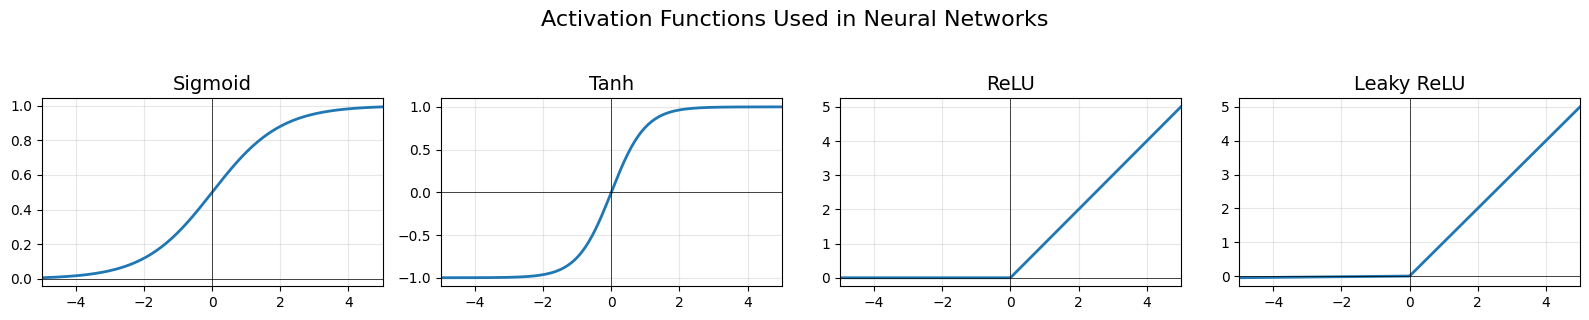

In [11]:
import matplotlib.pyplot as plt

# --- Activation Functions (used in every neural network) ---
x = np.linspace(-5, 5, 200)

# Common activation functions
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)
relu = np.maximum(0, x)
leaky_relu = np.where(x > 0, x, 0.01 * x)

fig, axes = plt.subplots(1, 4, figsize=(16, 3))
activations = [('Sigmoid', sigmoid), ('Tanh', tanh), ('ReLU', relu), ('Leaky ReLU', leaky_relu)]

for ax, (name, y) in zip(axes, activations):
    ax.plot(x, y, linewidth=2)
    ax.set_title(name, fontsize=14)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-5, 5)

plt.suptitle('Activation Functions Used in Neural Networks', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

---
## ✅ Key Takeaways

1. **Tensors** (multi-dimensional arrays) are the fundamental data structure in deep learning
2. **Broadcasting** lets you do operations on arrays with different shapes
3. **Matrix multiplication** (`@`) is the core operation of neural networks: `y = Wx + b`
4. **Reshaping** is needed constantly to move data between layers
5. **Activation functions** add non-linearity — without them, a deep network is just a linear function

---

## 📖 Next Steps
➡️ **Next notebook:** [02_pytorch_tensors_autograd.ipynb](02_pytorch_tensors_autograd.ipynb) — Learn PyTorch tensors and automatic differentiation